In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
print('Libraries loaded!')

Libraries loaded!


In [6]:
df = pd.read_csv('crime_incidents.csv')
print(f'Shape: {df.shape[0]} rows x {df.shape[1]} columns')
df.head()

Shape: 29303 rows x 25 columns


,X,Y,CCN,REPORT_DAT,START_DATE,END_DATE,BLOCK,OFFENSE,METHOD,SHIFT,...,BLOCK_GROUP,CENSUS_TRACT,VOTING_PRECINCT,BID,XBLOCK,YBLOCK,LATITUDE,LONGITUDE,OBJECTID,OCTO_RECORD_ID
0,406321.09,137111.49,24137087,2024/09/05 20:27:50+00,2024/09/05 18:13:00+00,2024/09/05 19:55:00+00,5067 - 5099 BLOCK OF JAY STREET NE,MOTOR VEHICLE THEFT,OTHERS,EVENING,...,007809 1,7809.0,Precinct 94,NaN,406321.09,137111.49,38.901835,-76.927127,931429856,NaN
1,403638.94,135772.42,24421597,2024/05/08 12:22:39+00,2024/04/28 01:00:00+00,2024/04/28 01:30:00+00,2300 - 3955 BLOCK OF EAST CAPITOL STREET,THEFT/OTHER,OTHERS,DAY,...,006804 1,6804.0,Precinct 80,NaN,403638.94,135772.42,38.889787,-76.958056,931429858,NaN
2,400366.22,132181.42,24048718,2024/04/01 20:11:32+00,2024/03/01 17:00:00+00,2024/03/28 20:00:00+00,2632 - 2663 BLOCK OF MARTIN LUTHER KING JR AVE...,THEFT/OTHER,OTHERS,EVENING,...,007401 2,7401.0,Precinct 119,ANACOSTIA,400366.22,132181.42,38.857445,-76.995781,931429859,NaN
3,397874.16,139955.89,24008097,2024/01/17 06:03:40+00,2024/01/17 05:05:00+00,2024/01/17 05:57:00+00,700 - 999 BLOCK OF HOBART PLACE NW,ROBBERY,GUN,MIDNIGHT,...,003100 1,3100.0,Precinct 37,NaN,397874.16,139955.89,38.927478,-77.024517,931429862,NaN
4,394784.25,137339.73,24421636,2024/05/09 13:22:10+00,2024/04/29 13:00:00+00,2024/04/30 13:30:00+00,1000 - 1099 BLOCK OF THOMAS JEFFERSON STREET NW,THEFT/OTHER,OTHERS,DAY,...,000102 3,102.0,Precinct 5,GEORGETOWN,394784.25,137339.73,38.903898,-77.060131,931429864,NaN


In [7]:
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")

Missing values per column:
X                           0
Y                           0
CCN                         0
REPORT_DAT                  0
START_DATE                  5
END_DATE                 2095
BLOCK                       0
OFFENSE                     0
METHOD                      0
SHIFT                       0
WARD                        4
ANC                         4
DISTRICT                  728
PSA                       454
NEIGHBORHOOD_CLUSTER        4
BLOCK_GROUP                13
CENSUS_TRACT               13
VOTING_PRECINCT             4
BID                     23884
XBLOCK                      0
YBLOCK                      0
LATITUDE                    0
LONGITUDE                   0
OBJECTID                    0
OCTO_RECORD_ID          29303
dtype: int64

Duplicate rows: 0


In [8]:
# Remove duplicates
df = df.drop_duplicates()

# Drop rows missing key columns
df = df.dropna(subset=['OFFENSE', 'WARD', 'SHIFT', 'METHOD', 'REPORT_DAT'])

# Convert dates and extract time info
df['REPORT_DAT'] = pd.to_datetime(df['REPORT_DAT'], errors='coerce')
df['MONTH'] = df['REPORT_DAT'].dt.month
df['DAY_OF_WEEK'] = df['REPORT_DAT'].dt.day_name()
df['HOUR'] = df['REPORT_DAT'].dt.hour

print(f"Clean dataset: {df.shape[0]} rows x {df.shape[1]} columns")

Clean dataset: 29299 rows x 28 columns


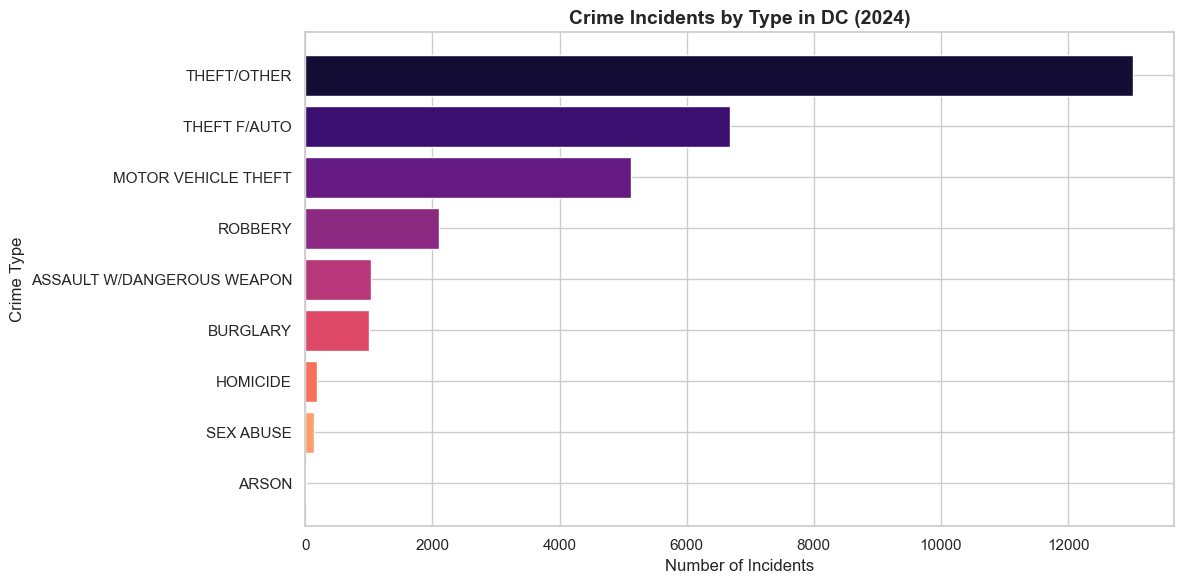

In [9]:
offense_counts = df['OFFENSE'].value_counts()

plt.figure(figsize=(12, 6))
plt.barh(offense_counts.index, offense_counts.values, 
         color=sns.color_palette('magma', len(offense_counts)))
plt.xlabel('Number of Incidents', fontsize=12)
plt.ylabel('Crime Type', fontsize=12)
plt.title('Crime Incidents by Type in DC (2024)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

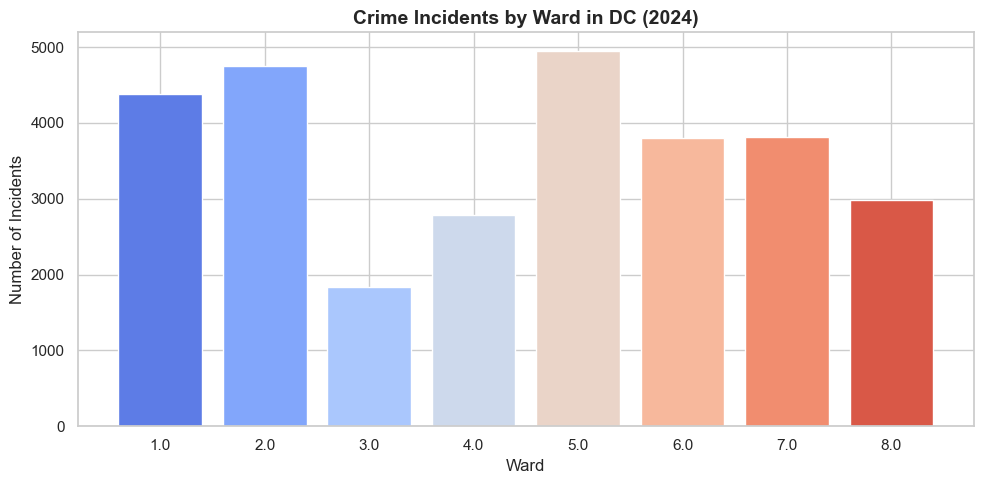

In [10]:
ward_counts = df['WARD'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.bar(ward_counts.index.astype(str), ward_counts.values,
        color=sns.color_palette('coolwarm', len(ward_counts)))
plt.xlabel('Ward', fontsize=12)
plt.ylabel('Number of Incidents', fontsize=12)
plt.title('Crime Incidents by Ward in DC (2024)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

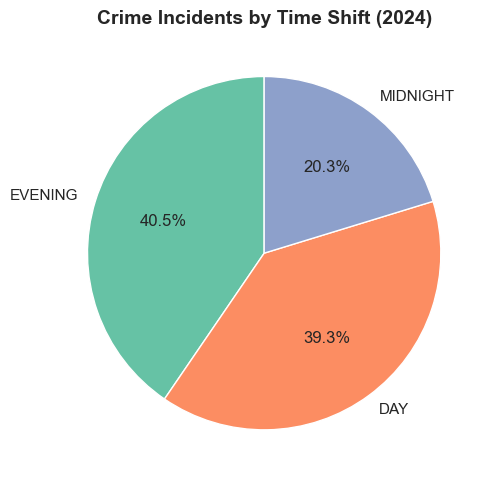

In [11]:
shift_counts = df['SHIFT'].value_counts()

plt.figure(figsize=(8, 5))
plt.pie(shift_counts.values, labels=shift_counts.index, autopct='%1.1f%%',
        colors=sns.color_palette('Set2', len(shift_counts)), startangle=90)
plt.title('Crime Incidents by Time Shift (2024)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

/var/folders/1h/tqqv9x_90xlf2h2tch4xzr540000gn/T/ipykernel_48700/3015197032.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=method_counts.index, y=method_counts.values, palette='viridis')


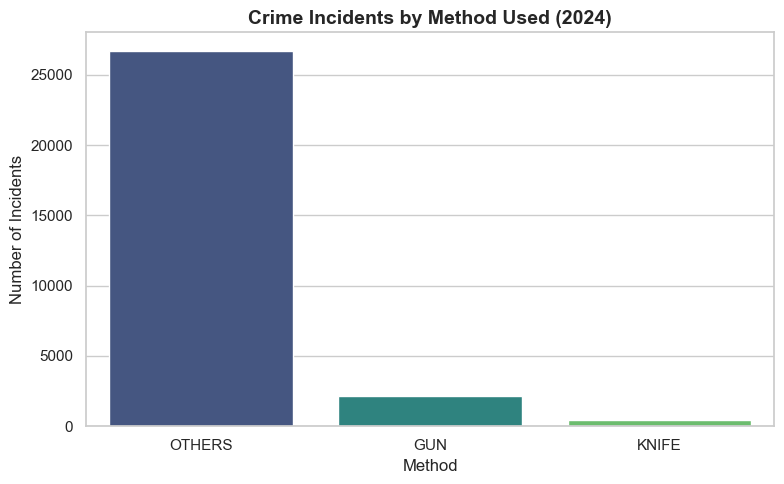

In [12]:
method_counts = df['METHOD'].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(x=method_counts.index, y=method_counts.values, palette='viridis')
plt.xlabel('Method', fontsize=12)
plt.ylabel('Number of Incidents', fontsize=12)
plt.title('Crime Incidents by Method Used (2024)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

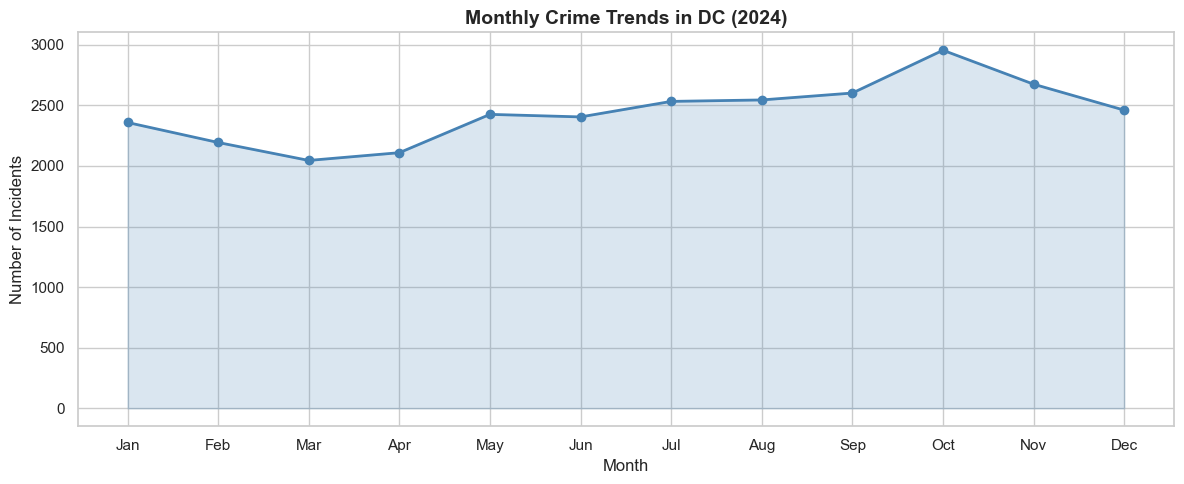

In [13]:
month_counts = df.groupby('MONTH').size().reset_index(name='COUNT')
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
month_counts['MONTH_LABEL'] = month_counts['MONTH'].apply(lambda x: month_names[x-1])

plt.figure(figsize=(12, 5))
plt.plot(month_counts['MONTH_LABEL'], month_counts['COUNT'],
         marker='o', color='steelblue', linewidth=2)
plt.fill_between(month_counts['MONTH_LABEL'], month_counts['COUNT'],
                 alpha=0.2, color='steelblue')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Incidents', fontsize=12)
plt.title('Monthly Crime Trends in DC (2024)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
print('=== SUMMARY STATISTICS ===')
print(f'Total crime incidents: {len(df):,}')
print(f'Most common crime: {df["OFFENSE"].mode()[0]}')
print(f'Number of unique crime types: {df["OFFENSE"].nunique()}')
print(f'Ward with most incidents: Ward {df["WARD"].value_counts().idxmax()}')
print(f'Most dangerous shift: {df["SHIFT"].value_counts().idxmax()}')
print(f'Most common method: {df["METHOD"].value_counts().idxmax()}')

=== SUMMARY STATISTICS ===
Total crime incidents: 29,299
Most common crime: THEFT/OTHER
Number of unique crime types: 9
Ward with most incidents: Ward 5.0
Most dangerous shift: EVENING
Most common method: OTHERS
